# Homework Assignment 10: Clustering
### Abdullah Junejo (07154)




In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

In [16]:
df = pd.read_csv('McDonaldsMenu.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    object 
 1   Item                           260 non-null    object 
 2   Serving Size                   260 non-null    object 
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int

## Q1,Q2,Q3

In [17]:
df.drop(['Serving Size','Category','Item'],axis=1,inplace=True) #cleanning
df

,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,300,120,13.0,20,5.0,25,0.0,260,87,750,...,31,10,4,17,3,17,10,0,25,15
1,250,70,8.0,12,3.0,15,0.0,25,8,770,...,30,10,4,17,3,18,6,0,25,8
2,370,200,23.0,35,8.0,42,0.0,45,15,780,...,29,10,4,17,2,14,8,0,25,10
3,450,250,28.0,43,10.0,52,0.0,285,95,860,...,30,10,4,17,2,21,15,0,30,15
4,400,210,23.0,35,8.0,42,0.0,50,16,880,...,30,10,4,17,2,21,6,0,25,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,510,150,17.0,26,9.0,44,0.5,45,14,280,...,80,27,1,4,64,12,15,0,40,8
256,690,200,23.0,35,12.0,58,1.0,55,19,380,...,106,35,1,5,85,15,20,0,50,10
257,340,100,11.0,17,6.0,29,0.0,30,9,190,...,53,18,1,2,43,8,10,0,25,6
258,810,290,32.0,50,15.0,76,1.0,60,20,400,...,114,38,2,9,103,21,20,0,60,6


In [18]:
scaler = MinMaxScaler() #Scaling
df_scaled = scaler.fit_transform(df)
df_scaled[1:5]

array([[0.13297872, 0.06603774, 0.06779661, 0.06593407, 0.15      ,
        0.14705882, 0.        , 0.04347826, 0.04166667, 0.21388889,
        0.21333333, 0.21276596, 0.21276596, 0.57142857, 0.60714286,
        0.0234375 , 0.20689655, 0.03529412, 0.        , 0.35714286,
        0.2       ],
       [0.19680851, 0.18867925, 0.19491525, 0.19230769, 0.4       ,
        0.41176471, 0.        , 0.07826087, 0.078125  , 0.21666667,
        0.22      , 0.20567376, 0.21276596, 0.57142857, 0.60714286,
        0.015625  , 0.16091954, 0.04705882, 0.        , 0.35714286,
        0.25      ],
       [0.2393617 , 0.23584906, 0.23728814, 0.23626374, 0.5       ,
        0.50980392, 0.        , 0.49565217, 0.49479167, 0.23888889,
        0.24      , 0.21276596, 0.21276596, 0.57142857, 0.60714286,
        0.015625  , 0.24137931, 0.08823529, 0.        , 0.42857143,
        0.375     ],
       [0.21276596, 0.19811321, 0.19491525, 0.19230769, 0.4       ,
        0.41176471, 0.        , 0.08695652, 0.0833333

# Q4

C:\Users\abdul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\abdul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\abdul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\abdul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are

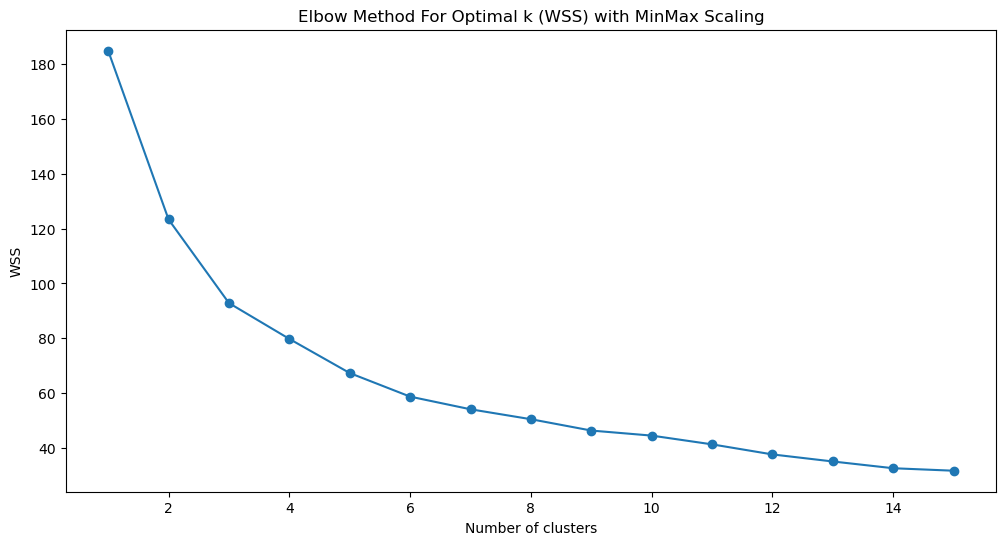

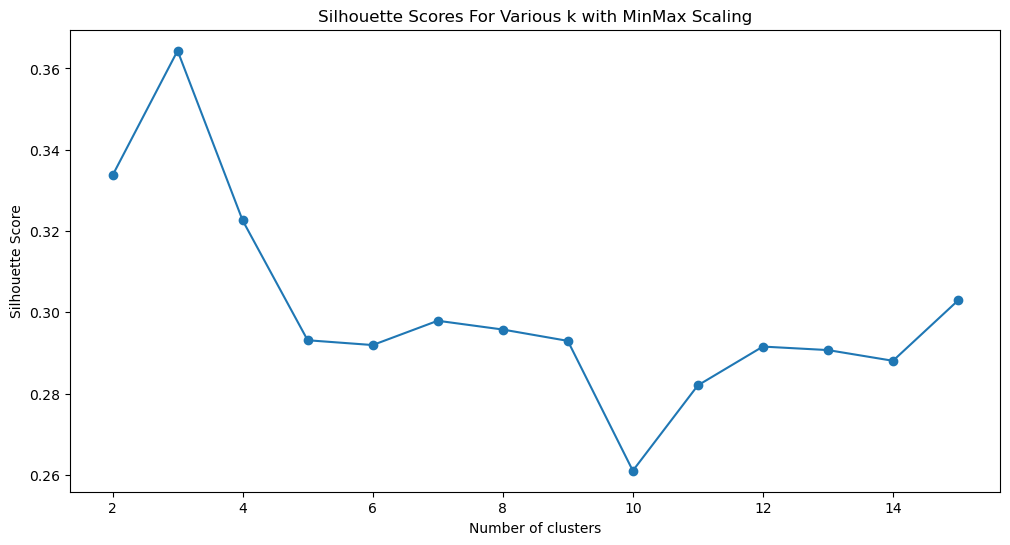

In [19]:
sil_score_minmax, wss_minmax = [],[]  #List to store Within-Cluster Sum of Square (WSS) values for MinMax scaled data and to store silhouette scores for MinMax scaled data

#Exploring clusters
for count in range(1, 16):
    kmeans = KMeans(n_clusters=count, max_iter=300, random_state=100)
    kmeans.fit(df_scaled)
    wss_minmax.append(kmeans.inertia_)  #Append the WSS value for each k
    if count > 1:
        labels = kmeans.labels_
        sil_score_minmax.append(silhouette_score(df_scaled, labels))  #Append silhouette score for each k

#Plotting the Elbow Method for WSS
plt.figure(figsize=(12, 6))
plt.plot(range(1, 16), wss_minmax, marker='o')
plt.title('Elbow Method For Optimal k (WSS) with MinMax Scaling')
plt.xlabel('Number of clusters')
plt.ylabel('WSS')
plt.show()

# Plotting the Silhouette Scores
plt.figure(figsize=(12, 6))
plt.plot(range(2, 16), sil_score_minmax, marker='o')
plt.title('Silhouette Scores For Various k with MinMax Scaling')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show() 

#Ignore the errors, scroll  down to see the graphs.

#### The graph exhibits a notable change in the slope of the Within-Cluster Sum of Square (WSS) curve at k=3, indicating a diminishing rate of decrease in WSS beyond this point. This suggests that 3 is the optimal number of clusters according to this method.  The Silhouette Score graph supports this conclusion by showing that the silhouette coefficient for k=3 is the closest to 1 among the tested range. A higher silhouette score indicates better-defined clusters, and thus, the score for k=3 reinforces the choice indicated by the Elbow Method.

# Q5

In [20]:
#Performing clustering with optimal numbers of cluster

kmeans = KMeans(n_clusters = 3, max_iter = 300, random_state = 100)
output = kmeans.fit_predict(df_scaled)
output

C:\Users\abdul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\abdul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0])

## Q6

Text(0.5, 1.0, 'Before Clustering')

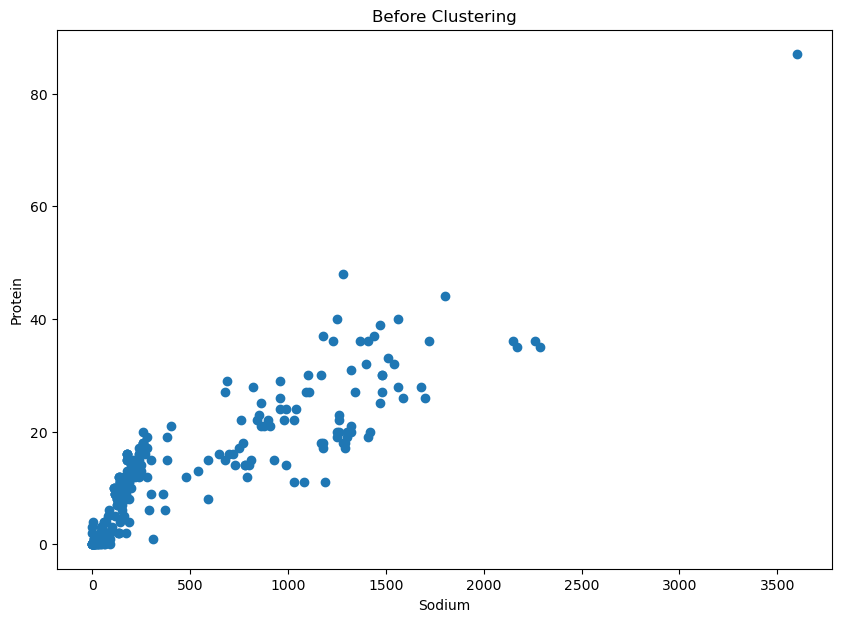

In [23]:
plt.figure(figsize=(10,7))
plt.scatter(x=df['Sodium'],y=df['Protein'])
plt.xlabel('Sodium')
plt.ylabel('Protein')
plt.title("Before Clustering")


### Positive Corelation before clustering. One outlier at the edge.

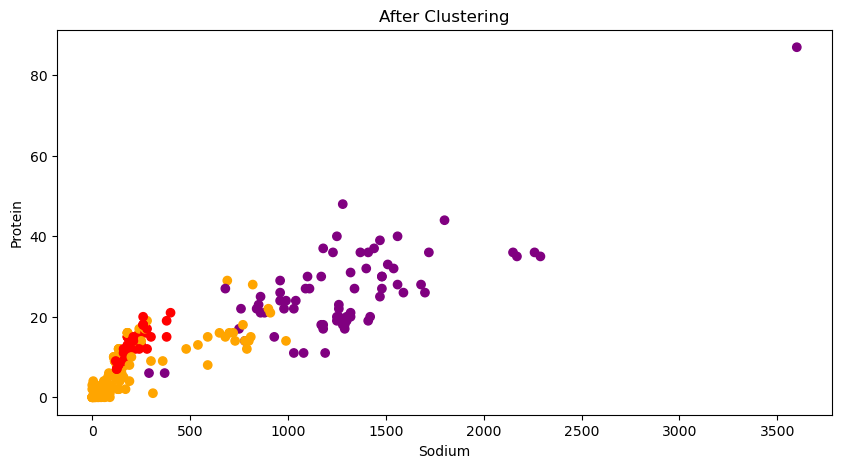

In [13]:
#Visualisation after clustering

plt.figure(figsize=(10,5))
colors = np.array(['orange', 'purple', 'red',])
plt.scatter(x = df['Sodium'], y = df['Protein'], c=colors[kmeans.labels_])
plt.xlabel('Sodium')
plt.ylabel('Protein')
plt.title('After Clustering')
plt.show()

### The above scatter plot is colour-coded according to cluster. Purple = High Sodium and High Protein | Orange = Low-Medium Protein and Sodium | Red = Low protein Low sodium.

## Q7, Q8, Q9

In [34]:
c1 = df.iloc[output == 0, :]
c2 = df.iloc[output == 1, :]
c3 = df.iloc[output == 2, :]

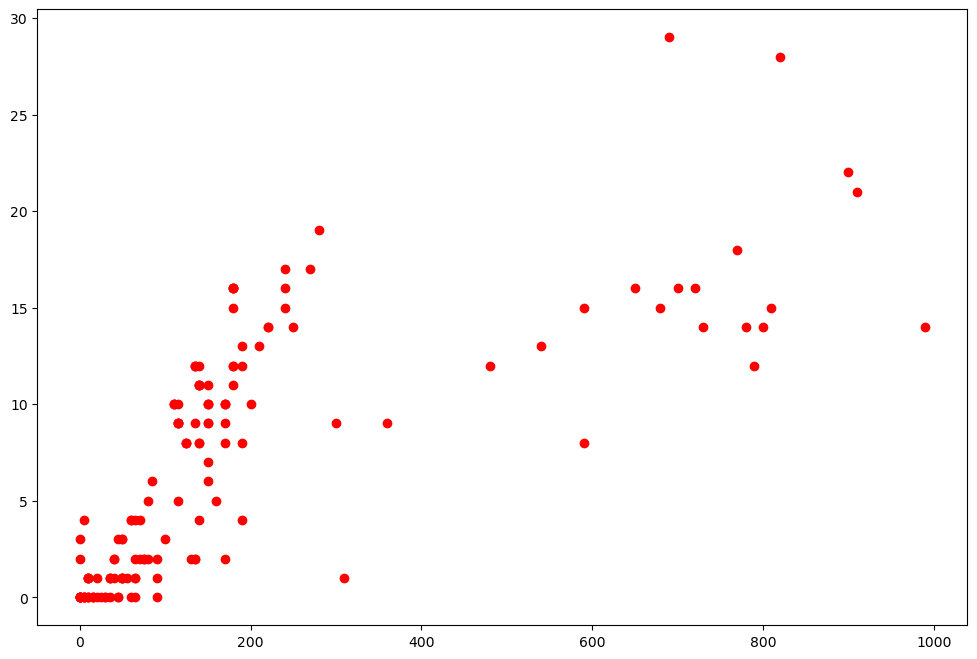

In [36]:
plt.figure(figsize=(12, 8))

# Plot each cluster
plt.scatter(c1['Sodium'], c1['Protein'], color='red', label='Cluster 1')

### Unique Cluster Name: Foodies | No particular preference for Sodium or Protein

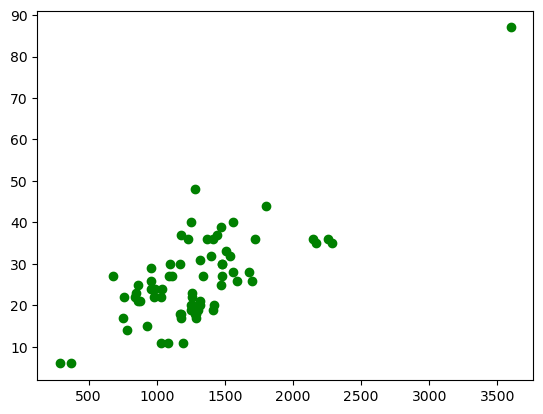

In [37]:
plt.scatter(c2['Sodium'], c2['Protein'], color='green', label='Cluster 2')

### Unique Cluster Name: Gym Enthusiasts | High Levels of Protein

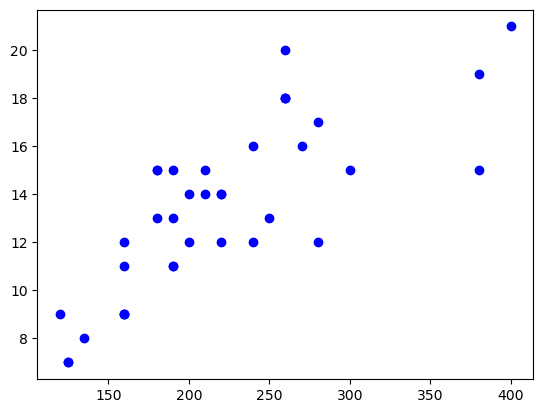

In [38]:
plt.scatter(c3['Sodium'], c3['Protein'], color='blue', label='Cluster 3')


### Fasting People | Very Low amount of sodium and protein spotted.

# 3 Insights

### Cluster 1 is High Sodium, Clluster 2 is High Protein and High Sodium, Cluster 3 is Low both. CLuster 1 is scattered and diverse which shows that foodies have diverse tastes, and preferences.

### Cluster 2 shows tighter plot which means that gym enthusiasts/ bulking people will be more strictly following a particular diet compared to foodies.

### Cluster 3 Shows that fasting people will have low intake of both but again due to diversity and personal preferences, there is a variaation.